### RANDOM FOREST
En este proyecto tomamos los datos procesados del Decision Tree para ver como mejora usando un Radom Forest

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
import argparse
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns       
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score   
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score   
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
import pandas as pd

X_train = pd.read_csv("data/raw/X_train_procesado.csv")
X_test  = pd.read_csv("data/raw/X_test_procesado.csv")
y_train = pd.read_csv("data/raw/y_train_procesado.csv")
y_test  = pd.read_csv("data/raw/y_test_procesado.csv")

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf.fit(X_train, y_train.values.ravel())

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test.values.ravel(), y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Random Forest -> Accuracy:", acc)
print("Random Forest -> AUC:", auc)
print()
print(classification_report(y_test, y_pred, digits=3))

Random Forest -> Accuracy: 0.7662337662337663
Random Forest -> AUC: 0.8188888888888889

              precision    recall  f1-score   support

           0      0.802     0.850     0.825       100
           1      0.688     0.611     0.647        54

    accuracy                          0.766       154
   macro avg      0.745     0.731     0.736       154
weighted avg      0.762     0.766     0.763       154



#### Ajuste de Hiperparametros

In [ ]:


# Si y_train / y_test vienen como DataFrame, aplana para evitar el warning
y_train_rf = y_train.values.ravel()
y_test_rf  = y_test.values.ravel()

rf_tuned = RandomForestClassifier(
    n_estimators=500,        # más árboles
    max_depth=8,            # limita profundidad para evitar sobreajuste
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # usa todos los cores
)

rf_tuned.fit(X_train, y_train_rf)

y_pred = rf_tuned.predict(X_test)
y_proba = rf_tuned.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test_rf, y_pred)
auc = roc_auc_score(y_test_rf, y_proba)

print("Random Forest ajustado -> Accuracy:", acc)
print("Random Forest ajustado -> AUC:", auc)
print()
print(classification_report(y_test_rf, y_pred, digits=3))

Random Forest ajustado -> Accuracy: 0.7532467532467533
Random Forest ajustado -> AUC: 0.8248148148148149

              precision    recall  f1-score   support

           0      0.810     0.810     0.810       100
           1      0.648     0.648     0.648        54

    accuracy                          0.753       154
   macro avg      0.729     0.729     0.729       154
weighted avg      0.753     0.753     0.753       154



In [ ]:
import pandas as pd

configs = []
for max_depth in [4, 6, 8, None]:
    for min_leaf in [1, 2, 4]:
        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train_rf)
        y_pred = rf.predict(X_test)
        y_proba = rf.predict_proba(X_test)[:, 1]
        acc = accuracy_score(y_test_rf, y_pred)
        auc = roc_auc_score(y_test_rf, y_proba)
        configs.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_leaf,
            "accuracy": acc,
            "auc": auc
        })

df_rf = pd.DataFrame(configs)
df_rf

,max_depth,min_samples_leaf,accuracy,auc
0,4.0,1,0.753247,0.818704
1,4.0,2,0.759740,0.821481
2,4.0,4,0.759740,0.817963
3,6.0,1,0.753247,0.830185
4,6.0,2,0.753247,0.823704
5,6.0,4,0.733766,0.825926
6,8.0,1,0.753247,0.825926
7,8.0,2,0.753247,0.830556
8,8.0,4,0.740260,0.825926
9,NaN,1,0.766234,0.822870


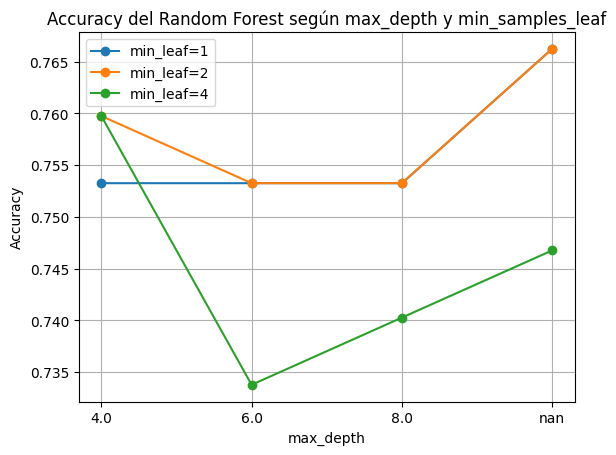

In [ ]:
import matplotlib.pyplot as plt

for min_leaf in [1, 2, 4]:
    sub = df_rf[df_rf["min_samples_leaf"] == min_leaf]
    x = sub["max_depth"].astype(str)  # para que None se vea como texto
    plt.plot(x, sub["accuracy"], marker="o", label=f"min_leaf={min_leaf}")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy del Random Forest según max_depth y min_samples_leaf")
plt.legend()
plt.grid(True)
plt.show()

#### Coclusion 

Las pruebas con Random Forest muestran que aumentar el número de árboles mejora ligeramente el rendimiento, pero el progreso más significativo proviene de ajustar la estructura de cada árbol (especialmente los hiperparámetros max_depth y min_samples_leaf), más que de incrementar solo n_estimators. En tus resultados, profundidades intermedias combinadas con un número reducido de muestras por hoja logran el mejor equilibrio entre precisión en el conjunto de prueba y capacidad de generalización, mientras que árboles demasiado profundos tienden a sobreajustar sin aportar mejoras claras en la precisión sobre los datos de test

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


y_train_rf = y_train.values.ravel()
y_test_rf  = y_test.values.ravel()

In [ ]:
# 2. Definimos la "rejilla" de parámetros a probar
param_grid_rf = {
    'n_estimators': [100, 300, 500],          # Número de árboles
    'max_depth': [5, 8, 12, None],            # Profundidad
    'min_samples_split': [2, 5, 10],          # Mínimo para dividir nodo
    'min_samples_leaf': [1, 2, 4],            # Mínimo en cada hoja
    'class_weight': ['balanced', 'balanced_subsample'] # Manejo de clases desbalanceadas
}

In [ ]:
# Configuramos el GridSearchCV
# Uso scoring='roc_auc' porque suele ser más robusto que accuracy en estos modelos
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,                 # 3 pliegues para no tardar una eternidad
    scoring='roc_auc', 
    verbose=1,            
    n_jobs=-1             
    
)

In [ ]:
# Entrenamos el buscador
print("Iniciando búsqueda de hiperparámetros (esto puede tardar)...")
grid_rf.fit(X_train, y_train_rf)

Iniciando búsqueda de hiperparámetros (esto puede tardar)...
Fitting 3 folds for each of 216 candidates, totalling 648 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [5, 8, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [ ]:
rf_final = grid_rf.best_estimator_

In [ ]:
# Predicciones con el ganador
y_pred = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]

In [ ]:
# 7. Resultados
print("\n--- MEJORES PARÁMETROS ENCONTRADOS ---")
print(grid_rf.best_params_)

print("\n--- RENDIMIENTO DEL MODELO OPTIMIZADO ---")
print(f"Accuracy: {accuracy_score(y_test_rf, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test_rf, y_proba):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_rf, y_pred, digits=3))


--- MEJORES PARÁMETROS ENCONTRADOS ---
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

--- RENDIMIENTO DEL MODELO OPTIMIZADO ---
Accuracy: 0.7468
AUC: 0.8220

Reporte de Clasificación:
              precision    recall  f1-score   support

           0      0.828     0.770     0.798       100
           1      0.623     0.704     0.661        54

    accuracy                          0.747       154
   macro avg      0.725     0.737     0.729       154
weighted avg      0.756     0.747     0.750       154



Resultados con el GridSearchCV

In [ ]:
# Lo que falta:
import joblib
joblib.dump(rf_tuned, '../models/random_forest_diabetes.pkl')